In [1]:
import pandas as pd
import numpy as np
import subprocess
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [ ]:
cmd = "cd ../terraform && echo $(terraform output -raw landing_bucket_name) $(terraform output -raw curated_bucket_name)"
output = subprocess.check_output(cmd, shell=True, text=True).strip()
LANDING_BUCKET, CURATED_BUCKET = output.split()
cmd = [
    "aws", "s3", "cp", 
    f"s3://{CURATED_BUCKET}/curated/sample_input.csv", 
    "./processed_output.csv"
]
subprocess.run(cmd, check=True)

In [3]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop="first") 

In [4]:
# Helper functions
def calculate_metrics(y_test, preds):
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2) Score: {r2:.2f}")

    return (mae, mse, rmse, r2)
    
def plot_pred_vs_true(y_test, preds):
    MIN_VALUE = 0
    MAX_VALUE = max(y_test)
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, preds)
    plt.plot([MIN_VALUE, MAX_VALUE], [MIN_VALUE, MAX_VALUE], '--k', label="Correct prediction")

    plt.title("Predicted vs. True Plot")
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.tight_layout()

def plot_residual(y_test, preds):
    residuals = y_test - preds
    plt.figure(figsize=(8, 8))
    plt.xlabel('Price')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.scatter(preds, residuals)
    plt.axhline(0, linestyle="--")

def get_z_score_scale(dataset, feature_name):
    feature = list(dataset[feature_name])
    mu = np.mean(feature)
    std = np.std(feature)
    return mu, std

def z_score_scale(dataset, feature_name, mu, std):
    dataset[feature_name] = [round((i - mu) / std, 2) for i in dataset[feature_name]]

# Helper functions - Data imputation:
def get_mode(dataset, feature_name):
    mode = dataset[feature_name].mode()
    return mode.iloc[0] if not mode.empty else "unknown"

def get_mean(dataset, feature_name):
    return round(np.nanmean(dataset[feature_name]), 1)

def fill_value(dataset, feature_name, value):
    dataset[feature_name] = dataset[feature_name].fillna(value)

# Helper functions - Conversion
def category_to_num(dataset, feature_name):
    feature = list(dataset[feature_name])
    elements = set(feature)
    
    categories = {}
    for i, e in enumerate(elements):
        if not categories.get(e):
            categories[e] = float(i)

    for i, e in enumerate(feature):
        feature[i] = categories[e]
    
    dataset[feature_name] = feature

def remove_row_due_missing_element(dataset, feature_name):
    return dataset.dropna(subset=[feature_name])

def one_hot_encode_train_test(X_train, X_test, feature_name):
    train_feature = X_train[[feature_name]]
    test_feature = X_test[[feature_name]]

    encoder.fit(train_feature)

    encoded_columns = encoder.get_feature_names_out([feature_name])

    train_encoded = encoder.transform(train_feature)
    test_encoded = encoder.transform(test_feature)

    train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_columns, index=X_train.index)
    test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_columns, index=X_test.index)

    X_train = pd.concat([X_train.drop(columns=[feature_name]), train_encoded_df], axis=1)

    X_test = pd.concat([X_test.drop(columns=[feature_name]), test_encoded_df], axis=1)

    return X_train, X_test


In [5]:
# Download aws s3 cp "s3://$CURATED_BUCKET/curated/test/sample_input.csv" ./processed_output.csv
dataset = pd.read_csv("./processed_output.csv")
independent_variables = dataset.drop(columns=["price"])
dependent_variable = dataset["price"]
seed=42

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   carname           235 non-null    str    
 1   fueltype          235 non-null    str    
 2   aspiration        235 non-null    str    
 3   doornumber        235 non-null    str    
 4   carbody           235 non-null    str    
 5   drivewheel        235 non-null    str    
 6   enginelocation    226 non-null    str    
 7   wheelbase         235 non-null    float64
 8   color             235 non-null    str    
 9   carlength         231 non-null    float64
 10  carwidth          235 non-null    float64
 11  carheight         235 non-null    float64
 12  curbweight        235 non-null    int64  
 13  cylindernumber    227 non-null    float64
 14  enginesize        235 non-null    int64  
 15  compressionratio  235 non-null    float64
 16  horsepower        235 non-null    float64
 17  peakrpm 

In [7]:
categorical_features = ["carname", "fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation", "color"]

# To avoid data leakage, we first split the data into train and test sets. I will use 80% train, and 20% test set.
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=0.2, shuffle=True)

In [8]:
X_train.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg
count,188.000000,185.000000,188.000000,188.000000,188.000000,183.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,98.380319,173.285405,65.696277,53.600532,2514.223404,4.284153,123.446809,10.160266,100.553191,5108.510638,25.494681,31.111702
std,5.875025,11.877443,2.005457,2.491429,486.351750,0.905490,36.861242,4.038651,34.076076,482.813629,6.389746,6.720013
min,86.600000,141.100000,60.300000,48.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,14.000000,16.000000
25%,94.500000,166.300000,64.000000,51.600000,2143.750000,4.000000,97.750000,8.500000,70.000000,4800.000000,20.750000,25.000000
50%,96.500000,172.400000,65.400000,53.800000,2403.000000,4.000000,110.500000,9.000000,94.500000,5100.000000,25.000000,30.000000
75%,100.400000,178.200000,66.500000,55.500000,2826.250000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.500000
max,120.900000,208.100000,72.000000,59.800000,4066.000000,8.000000,308.000000,23.000000,207.000000,6600.000000,49.000000,54.000000


In [9]:
X_train.isna().sum()

carname             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      4
wheelbase           0
color               0
carlength           3
carwidth            0
carheight           0
curbweight          0
cylindernumber      5
enginesize          0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
dtype: int64

In [10]:
X_test.isna().sum()

carname             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      5
wheelbase           0
color               0
carlength           1
carwidth            0
carheight           0
curbweight          0
cylindernumber      3
enginesize          0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
dtype: int64

In [11]:
# DATA IMPUTATION
for feature in ["enginelocation"]:
    value = get_mode(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

for feature in ["carlength", "cylindernumber"]:
    value = get_mean(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

# DATA CONVERSION
for feature in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train, X_test, feature)

In [12]:
# Scale the data
features_to_scale = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "compressionratio", "horsepower", "peakrpm", "highwaympg", "citympg", "cylindernumber"]

# Scale train
for feature in features_to_scale:
    mu, std = get_z_score_scale(X_train, feature)
    z_score_scale(X_train, feature, mu, std)
    z_score_scale(X_test, feature, mu, std)

In [13]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 188 entries, 117 to 102
Data columns (total 57 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   wheelbase            188 non-null    float64
 1   carlength            188 non-null    float64
 2   carwidth             188 non-null    float64
 3   carheight            188 non-null    float64
 4   curbweight           188 non-null    float64
 5   cylindernumber       188 non-null    float64
 6   enginesize           188 non-null    float64
 7   compressionratio     188 non-null    float64
 8   horsepower           188 non-null    float64
 9   peakrpm              188 non-null    float64
 10  citympg              188 non-null    float64
 11  highwaympg           188 non-null    float64
 12  carname_audi         188 non-null    float64
 13  carname_bmw          188 non-null    float64
 14  carname_buick        188 non-null    float64
 15  carname_chevrolet    188 non-null    float64
 16  carn

In [14]:
# 1. experiment: BASELINE. Simple linear regression.
# That 0.95 multiplying is my slightly underestimation. It's not robust.
simple_linear_model = LinearRegression()
simple_linear_model.fit(X_train, y_train)
simple_linear_model_preds = simple_linear_model.predict(X_test) * 0.95
simple_linear_model_preds_on_train = simple_linear_model.predict(X_train) * 0.95

print("Train set performance: \n")
mae, mse, rmse, r2 = calculate_metrics(y_test=y_train, preds=simple_linear_model_preds_on_train)
print("\nTest set performance: \n")
calculate_metrics(y_test=y_test, preds=simple_linear_model_preds)

Train set performance: 

Mean Absolute Error (MAE): 1146.82
Mean Squared Error (MSE): 2399665.33
Root Mean Squared Error (RMSE): 1549.09
R-squared (R2) Score: 0.95

Test set performance: 

Mean Absolute Error (MAE): 1814.19
Mean Squared Error (MSE): 10332477.97
Root Mean Squared Error (RMSE): 3214.42
R-squared (R2) Score: 0.89


(1814.185075553806, 10332477.966472458, 3214.4172047935, 0.89102843811472)

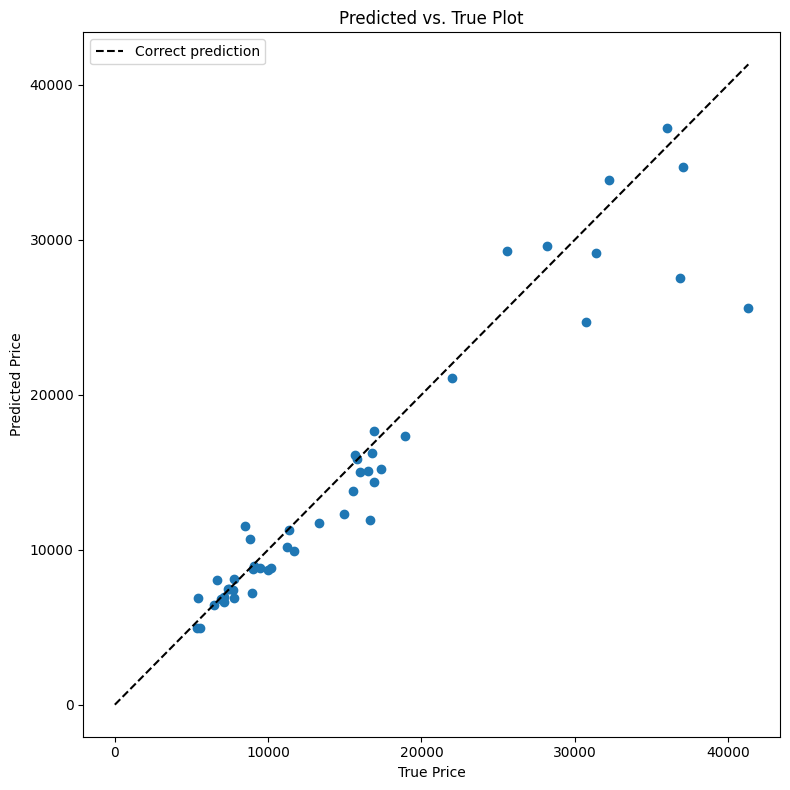

In [15]:
plot_pred_vs_true(y_test, simple_linear_model_preds)

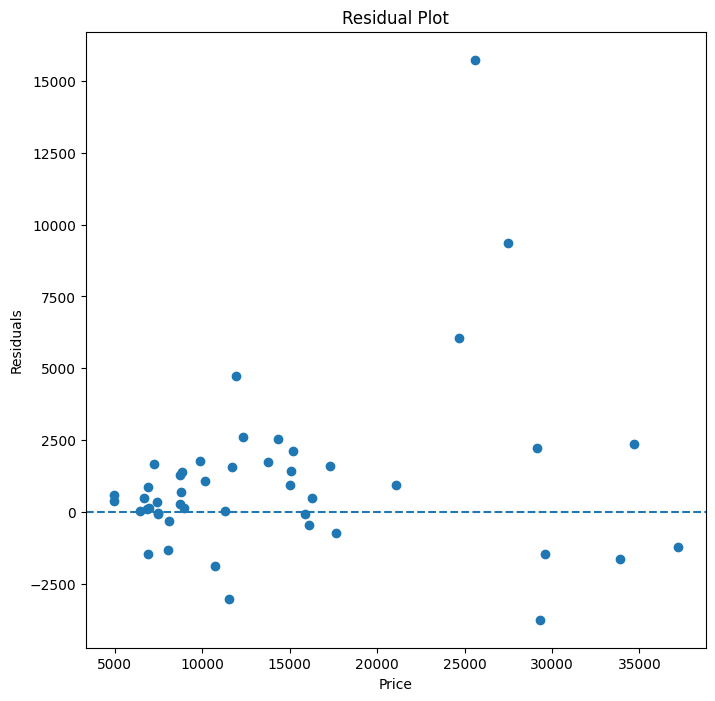

In [16]:
plot_residual(y_test, simple_linear_model_preds)

In [17]:
# I see inconsistency in higher prices. 
# Some show high errors in the positive side, some in the negative side. 
# This means that my model missing important features or shows us heteroscedasticity. 

# But first I try out log scaling on prices, on the target variable. This often helps when expensive items have much larger errors than cheaper items.

In [18]:
# 2. experiment: log transform of the price
dependent_variable_log = np.log1p(dependent_variable)
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable_log, random_state=seed, test_size=0.2, shuffle=True)

In [19]:
# DATA IMPUTATION AGAIN
for feature in ["enginelocation"]:
    value = get_mode(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

for feature in ["carlength", "cylindernumber"]:
    value = get_mean(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

# DATA CONVERSION
for feature in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train, X_test, feature)

# Scale the data
features_to_scale = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "compressionratio", "horsepower", "peakrpm", "highwaympg", "citympg", "cylindernumber"]

# Scale train
for feature in features_to_scale:
    mu, std = get_z_score_scale(X_train, feature)
    z_score_scale(X_train, feature, mu, std)
    z_score_scale(X_test, feature, mu, std)

In [20]:
simple_linear_model.fit(X_train, y_train)
simple_linear_model_preds = simple_linear_model.predict(X_test)
simple_linear_model_preds_on_train = simple_linear_model.predict(X_train)

# We shift back to normal domain the prices
simple_linear_model_preds = np.expm1(simple_linear_model_preds) * 0.95
simple_linear_model_preds_on_train = np.expm1(simple_linear_model_preds_on_train)  * 0.95


y_train = np.expm1(y_train)
y_test = np.expm1(y_test)

print("Train set performance: \n")
mae, mse, rmse, r2 = calculate_metrics(y_test=y_train, preds=simple_linear_model_preds_on_train)
print("\nTest set performance: \n")
calculate_metrics(y_test=y_test, preds=simple_linear_model_preds)

Train set performance: 

Mean Absolute Error (MAE): 1070.40
Mean Squared Error (MSE): 2737537.21
Root Mean Squared Error (RMSE): 1654.55
R-squared (R2) Score: 0.94

Test set performance: 

Mean Absolute Error (MAE): 1795.85
Mean Squared Error (MSE): 6459825.86
Root Mean Squared Error (RMSE): 2541.62
R-squared (R2) Score: 0.93


(1795.8516633821735, 6459825.863220523, 2541.6187485971464, 0.9318713946348347)

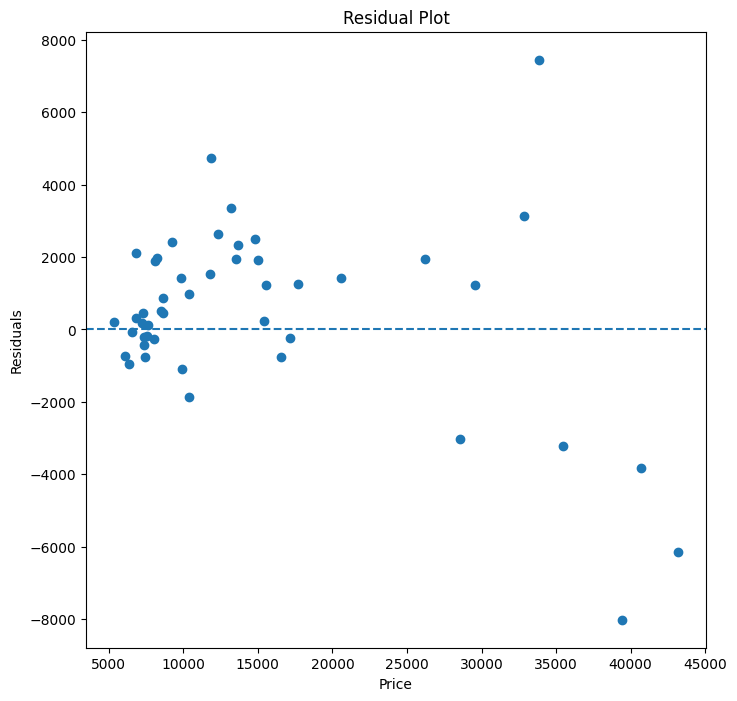

In [21]:
plot_residual(y_test, simple_linear_model_preds)

In [22]:
simple_linear_model_preds

array([10352.98837621,  7290.5564837 ,  8082.52347715, 29543.33830292,
        8500.69275558,  7372.72725482, 11768.13221699,  7651.34382129,
       28588.07265868, 14995.57707894, 14828.3773233 , 16576.6751455 ,
        6819.33461431,  6067.80277476, 13555.23010471, 26242.55375592,
       20609.33301205, 39414.99779804,  9271.72743324, 15447.56751855,
       12314.34133703,  9936.63078088, 33868.91602309,  7465.93289104,
        6348.83185171, 15533.06601719, 13659.48148763, 13169.36453051,
        7600.73948339,  5370.35460287, 35476.77173152, 43163.63783905,
        6546.08138299,  8637.37046346, 11891.98656434, 40695.3735183 ,
        6817.54203894,  9833.96335276,  8026.12699201, 17158.07537317,
        8233.49970562, 17666.11332436,  7340.51381491, 10378.12604608,
       32862.37365943,  7226.79302809,  8628.37140796])

In [23]:
errors = X_test.copy()
errors["true_price"] = y_test
errors["pred_price"] = simple_linear_model_preds
errors["residual"] = errors["true_price"] - errors["pred_price"]
errors.sort_values("residual").head(10)

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,...,color_navy,color_olive,color_purple,color_silver,color_teal,color_white,color_yellow,true_price,pred_price,residual
112,0.00,0.21,3.30,-1.25,1.76,4.17,2.16,-0.04,5.52,1.33,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31400.5,39414.997798,-8014.497798
66,-1.52,-0.37,-0.35,-0.81,0.59,1.93,1.92,-0.16,3.13,1.64,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37028.0,43163.637839,-6135.637839
170,1.98,2.02,2.60,1.09,2.04,1.93,2.33,-0.54,2.40,0.61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36880.0,40695.373518,-3815.373518
146,2.50,2.24,1.95,-0.32,3.20,1.93,3.66,-0.51,2.22,-0.74,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,32250.0,35476.771732,-3226.771732
223,1.98,1.50,2.30,1.17,2.06,0.80,1.62,2.82,0.66,-1.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25552.0,28588.072659,-3036.072659
69,0.07,0.38,0.40,0.76,-0.21,-0.32,-0.04,-0.39,-0.49,-0.64,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8495.0,10352.988376,-1857.988376
10,0.07,0.38,0.40,0.04,-0.27,-0.32,-0.04,-0.39,-0.49,-0.64,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8845.0,9936.630781,-1091.630781
221,-0.80,-1.98,-0.85,-0.40,-1.40,0.02,-1.21,-0.01,-1.19,0.81,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5408.0,6348.831852,-940.831852
55,1.04,1.24,0.40,0.20,1.27,0.02,1.29,-0.24,1.63,0.19,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,15805.0,16576.675145,-771.675145
144,-0.90,-0.55,-0.75,0.20,-1.17,-0.32,-0.88,-0.29,-0.96,-0.23,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6695.0,7465.932891,-770.932891


In [24]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": simple_linear_model.coef_
}).sort_values("coef", ascending=False)

coef_df.head(20)

,feature,coef
42,enginelocation_rear,0.480114
13,carname_bmw,0.317980
26,carname_porsche,0.252301
4,curbweight,0.201472
0,wheelbase,0.127507
11,highwaympg,0.095356
34,aspiration_turbo,0.093814
28,carname_saab,0.068186
2,carwidth,0.046628
8,horsepower,0.043730


In [25]:
X_train.columns

Index(['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'cylindernumber', 'enginesize', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'carname_audi', 'carname_bmw',
       'carname_buick', 'carname_chevrolet', 'carname_dodge', 'carname_honda',
       'carname_isuzu', 'carname_jaguar', 'carname_mazda', 'carname_mercury',
       'carname_mitsubishi', 'carname_nissan', 'carname_peugeot',
       'carname_plymouth', 'carname_porsche', 'carname_renault',
       'carname_saab', 'carname_subaru', 'carname_toyota',
       'carname_volkswagen', 'carname_volvo', 'fueltype_gas',
       'aspiration_turbo', 'doornumber_two', 'carbody_hardtop',
       'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd',
       'drivewheel_rwd', 'enginelocation_rear', 'color_black', 'color_blue',
       'color_fuchsia', 'color_gray', 'color_green', 'color_lime',
       'color_maroon', 'color_navy', 'color_olive', 'color_purple',
       'color_si

In [26]:
# 3. experiment: Add some regularization
from sklearn.linear_model import Ridge

for alpha in [0.1, 1, 5, 10, 20, 50, 100]:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    preds = ridge_model.predict(X_test) * 0.95

    print("alpha:", alpha)
    calculate_metrics(y_test, preds)

alpha: 0.1
Mean Absolute Error (MAE): 1802.87
Mean Squared Error (MSE): 10201148.78
Root Mean Squared Error (RMSE): 3193.92
R-squared (R2) Score: 0.89
alpha: 1
Mean Absolute Error (MAE): 1894.50
Mean Squared Error (MSE): 10529785.23
Root Mean Squared Error (RMSE): 3244.96
R-squared (R2) Score: 0.89
alpha: 5
Mean Absolute Error (MAE): 2127.94
Mean Squared Error (MSE): 12868535.83
Root Mean Squared Error (RMSE): 3587.27
R-squared (R2) Score: 0.86
alpha: 10
Mean Absolute Error (MAE): 2275.26
Mean Squared Error (MSE): 14375399.08
Root Mean Squared Error (RMSE): 3791.49
R-squared (R2) Score: 0.85
alpha: 20
Mean Absolute Error (MAE): 2388.64
Mean Squared Error (MSE): 16004538.99
Root Mean Squared Error (RMSE): 4000.57
R-squared (R2) Score: 0.83
alpha: 50
Mean Absolute Error (MAE): 2508.03
Mean Squared Error (MSE): 18449738.64
Root Mean Squared Error (RMSE): 4295.32
R-squared (R2) Score: 0.81
alpha: 100
Mean Absolute Error (MAE): 2621.63
Mean Squared Error (MSE): 20987093.14
Root Mean Squared

In [27]:
# 4. experiment: Feature engineering.

In [28]:
# I will continue with engineered features.
def add_engineered_features(df):
    df = df.copy()

    df["car_volume"] = df["carlength"] * df["carwidth"] * df["carheight"]
    df["power_to_weight"] = df["horsepower"] / df["curbweight"]
    df["engine_power_ratio"] = df["horsepower"] / df["enginesize"]
    df["engine_per_weight"] = df["enginesize"] / df["curbweight"]
    df["width_to_length"] = df["carwidth"] / df["carlength"]

    return df

X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=0.2, shuffle=True)


# DATA IMPUTATION
for feature in ["enginelocation"]:
    value = get_mode(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

for feature in ["carlength", "cylindernumber"]:
    value = get_mean(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

# DATA CONVERSION
for feature in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train, X_test, feature)


# Scale the data
features_to_scale = ["car_volume", "power_to_weight", "engine_power_ratio", "engine_per_weight", "width_to_length", "wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "compressionratio", "horsepower", "peakrpm", "highwaympg", "citympg", "cylindernumber"]

# Scale train
for feature in features_to_scale:
    mu, std = get_z_score_scale(X_train, feature)
    z_score_scale(X_train, feature, mu, std)
    z_score_scale(X_test, feature, mu, std)

Engineered Linear Model - Train set performance:

Mean Absolute Error (MAE): 1058.87
Mean Squared Error (MSE): 1903340.80
Root Mean Squared Error (RMSE): 1379.62
R-squared (R2) Score: 0.96

Engineered Linear Model - Test set performance:

Mean Absolute Error (MAE): 1854.01
Mean Squared Error (MSE): 10341840.66
Root Mean Squared Error (RMSE): 3215.87
R-squared (R2) Score: 0.89


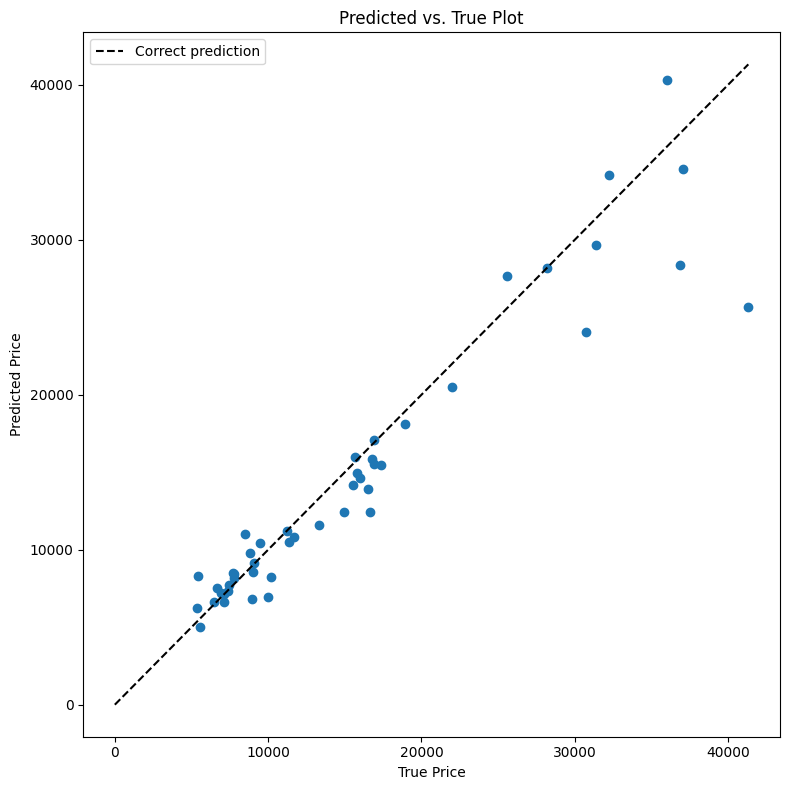

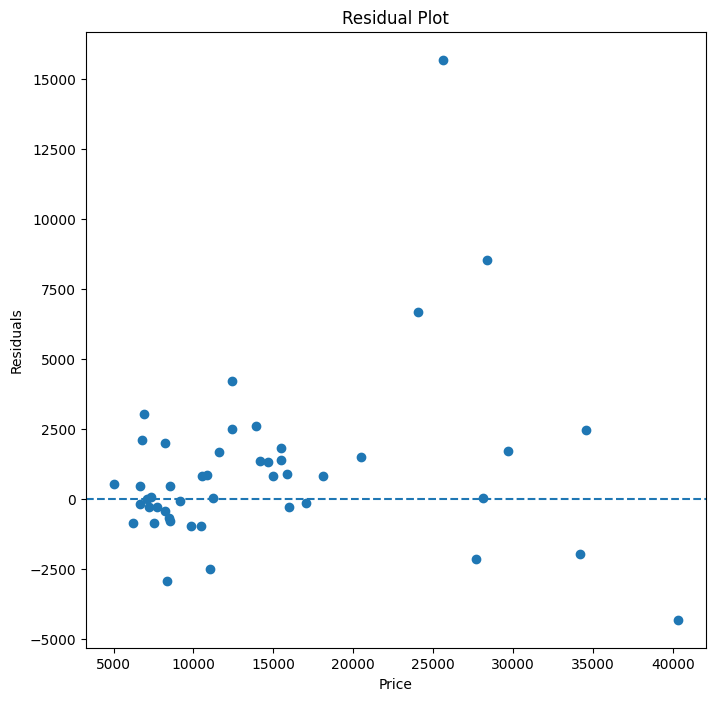

In [29]:
engineered_linear_model = LinearRegression()
engineered_linear_model.fit(X_train, y_train)

engineered_train_preds = engineered_linear_model.predict(X_train) * 0.95
engineered_test_preds = engineered_linear_model.predict(X_test) * 0.95

print("Engineered Linear Model - Train set performance:\n")
calculate_metrics(y_train, engineered_train_preds)

print("\nEngineered Linear Model - Test set performance:\n")
calculate_metrics(y_test, engineered_test_preds)

plot_pred_vs_true(y_test, engineered_test_preds)
plot_residual(y_test, engineered_test_preds)